# Bepaling van warmtecapaciteit van een onbekend materiaal


# Introductie

Onbekende materialen kunnen geïdentificeerd worden door hun eigenschappen te meten. Een van deze eigenschappen is de warmtecapaciteit. In dit practicum gaan we de warmtecapaciteit van een onbekend materiaal bepalen door middel van een calorimeter experiment. Daarbij wordt een bepaalde massa van het materiaal naar een bekende temperatuur gebracht waarna het in een bekende hoeveelheid water met bekende temperatuur wordt geplaatst. Door de temperatuur van het water te meten na het mengen kan de warmtecapaciteit van het onbekende materiaal worden berekend.

# Theorie

De soortelijke warmte $c$ van een materiaal is gedefinieerd als de hoeveelheid warmte $Q$ die nodig is om de temperatuur $T$ van een kilogram van het materiaal met één graad Celsius (of één Kelvin) te verhogen:

$$
    c = \frac{Q}{m \Delta T}
$$ (eq:heat_capacity)

Waarbij $Q$ de hoeveelheid warmte in Joules is, $m$ de massa in kilogram is en $\Delta T$ de verandering in temperatuur is. Gegeven de wet van Black, die stelt dat de totale hoeveelheid warmte in een geïsoleerd systeem constant blijft, kunnen we de warmte die het onbekende materiaal verliest gelijkstellen aan de warmte die het water opneemt:

$$
    Q_{materiaal} = -Q_{water} 
$$ (eq:black)

wanneer we de massa's en de begintemperaturen van beide systemen kennen, maar slechts een van de twee soortelijke warmtes, kunnen we de onbekende soortelijke warmte berekenen. We combineren vergelijkingen [](#eq:heat_capacity) en [](#eq:black) om de volgende vergelijking te krijgen:

$$
    T_e = \frac{c_w m_w T_{w,b}+c_m m_m T_{m,b}}{c_w m_w + c_m m_m}
$$ (eq:combined)

Waarbij de subscripts $b$ en $e$ respectievelijk staan voor begintoestand en eindtoestand, $w$ voor water en $m$ voor het onbekende materiaal.

Bij metingen aan verschillende massa's van het onbekende materiaal en vervolgens een least square fit aan bovenstaande vergelijking kunnen we een precieze waarde voor de soortelijke warmte van het onbekende materiaal bepalen. Dat is, wanneer de warmtecapaciteit van bijvoorbeeld de beker te verwaarlozen is.


# Methode en materialen

## Ontwerp
De bovenstaande theorie wordt gebruikt om de soortelijke warmte van een onbekend materiaal te bepalen. Het experiment bestaat uit het verwarmen van verschillende massa's van het onbekende materiaal tot een bekende temperatuur, waarna het in een bekende hoeveelheid water met bekende temperatuur wordt geplaats. Door de temperatuur van het water te meten na het mengen kan de warmtecapaciteit van het onbekende materiaal worden berekend. Om de tijd voor het meten van meerdere materialen te reduceren, worden de data van de verschillende groepen in het lokaal samengevoegd. Van tevoren is afgesproken welke massa's door welke groep worden gemeten, en hoeveel water er gebruikt wordt.

## Materialen
Hieronder staat de lijst van benodigde materialen bij deze proef:
- Calorimeter
- Thermometer of temperatuursensor
- Verwarmingsbron 
- Diverse massablokjes van onbekend materiaal
- Weegschaal
- Water
- Maatcilinder of maatbeker


```{figure} figures/c_onbekend_setup.jpg
:width: 70%
:label: fig_c_onbekend_setup

Een schematische weergave van de opstelling
```


## Procedure
Bespreek wie welke massa's van het onbekende materiaal gaat meten.
Bespreek ook hoeveel water er gebruikt gaat worden.
Bepaal de begintemperaturen.
Hevel het aantal afgesproken massa's in de maatbeker. 
Roer voorzicht zodat de temperatuur homogeen is.
Noteer de hoogste gemeten temperatuur, dit is $T_e$.
Wissel de metingen uit met de andere groepen en voer de data-analyse uit.

```{note}
Hieronder staat een voorbeeld hoe je een grafiek moet opslaan en vervolgens in je document kunt oproepen.
Het voorbeeld kun je natuurlijk straks verwijderen.
```

# Resultaten


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit  

In [2]:
#Raw-data: 

t = np.array([241.8, 374.01, 361.54, 207.83, 215.91])
m_w   = np.array([0.1378, 0.1386, 0.1386, 0.1391, 0.1391])  # kg
m_nb = np.array([0.0645, 0.0517, 0.0386, 0.0138, 0.0268]) #kg
T_w_b = np.array([20.2, 19.9, 20.3, 20.0, 20.4]) #celcius
T_m_b = np.array([69.2, 69.2, 68.9, 69.2, 68.9]) #celcius
T_e = np.array([22.2, 21.7, 21.5, 20.9, 21.5]) #celcius


In [3]:
#C_w waarde:
c = 4651.04 #gevonden soortelijke warmte van water in J/(kg·K)
c_w = c  # J/(kg·K) 

m_nb = m_nb
T_m_b = np.mean(T_m_b) + 273.15 #Kelvin
m_w = np.mean(m_w)
T_w_b = np.mean(T_w_b) + 273.15   #Kelvin
T_e = T_e +273.15   #Kelvin
T_e_error = 0.05/np.sqrt(5) #want gemeten op 0.1 graden nauwkeurig



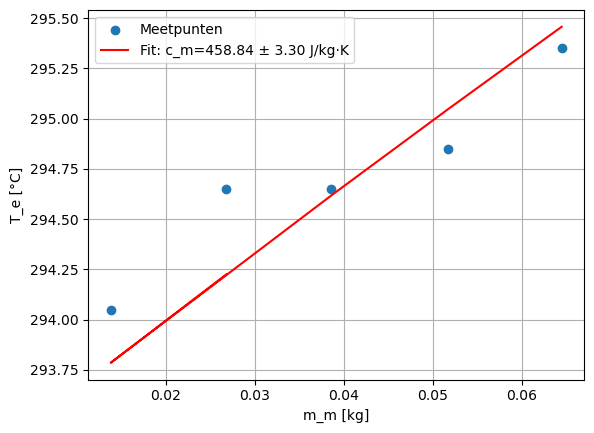

Beste schatting van de soortelijke warmte c_m: 458.84 J/(kg·K)
Standaardfout van de fit: 3.30 J/(kg·K)
Totale warmtecapaciteit per blok:
1: 29.6 J/K
2: 23.7 J/K
3: 17.7 J/K
4: 6.33 J/K
5: 12.3 J/K


In [4]:
# Theoretisch model:
def Te_fit(m_nb, c_nb):
    return (c_w * m_w * T_w_b + c_nb * m_nb * T_m_b) / (c_w * m_w + c_nb * m_nb) #c_m wil je weten om warmtecapciteit van deze onbekend stop te beapeln

# Curve fit
popt, pcov = curve_fit(Te_fit, m_nb, T_e, sigma=T_e_error, absolute_sigma=True)
c_nb_best= popt[0]
c_nb_error = np.sqrt(np.diag(pcov))[0]

# Bereken warmtecapaciteit per blok
C_nb = c_nb_best * m_nb

# Plot
T_fit = Te_fit(m_nb, c_nb_best)
plt.scatter(m_nb, T_e, label="Meetpunten")
plt.plot(m_nb, T_fit, color='red', label=f"Fit: c_m={c_nb_best:.2f} ± {c_nb_error:.2f} J/kg·K")
plt.xlabel("m_m [kg]")
plt.ylabel("T_e [°C]")
plt.legend()
plt.grid(True)

plt.savefig("Curve fit", dpi=450)  
plt.show()

# Resultaten printen
print(f"Beste schatting van de soortelijke warmte c_m: {c_nb_best:.2f} J/(kg·K)")
print(f"Standaardfout van de fit: {c_nb_error:.2f} J/(kg·K)")
print("Totale warmtecapaciteit per blok:")
for i, C in enumerate(C_nb):
    print(f"{i+1}: {C:.3g} J/K")

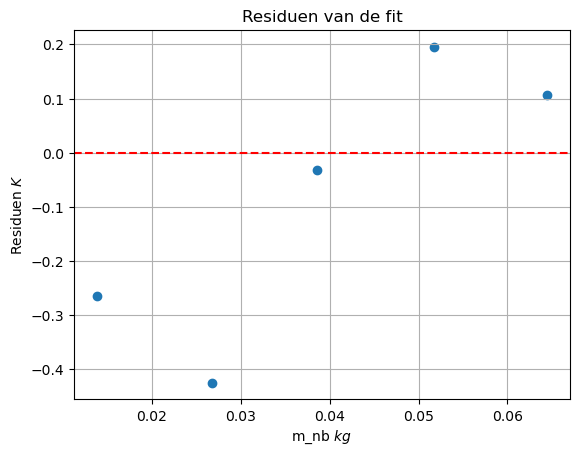

In [5]:
#Residuen plot:
residuals = Te_fit(m_nb, c_nb_best) -T_e

plt.figure()
plt.scatter(m_nb, residuals) 
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("m_nb $kg$ ")      
plt.ylabel("Residuen $K$")
plt.title("Residuen van de fit")
plt.grid(True)

plt.savefig("Residuen", dpi=450)  

plt.show()


# Discussie

Uit de least‑squares fit van het theoretische model op de gemeten data volgt een waarde voor de soortelijke warmte van het onbekende materiaal van 458.84 J/(kg*K) met een bijbehorende onzekerheid van 3.30 J/K. Dit geeft de volgende wamrtecapciteiten van de onbekende stof: 29.6 J/K, 23.7 J/K, 17.7 J/K, 6.33 J/K, 12.3 J/K.

De fitlijn beschrijft de trend over het algemeen, maar gaat niet exact door alle meetpunten heen. Drie gemeten punten liggen namelijk boven de fit en twee eronder. Dit is normaal bij een statistische fit, omdat het model een gemiddelde relatie beschrijft en niet bedoeld is om alle meetpunten exact te interpoleren.

De residuenplot laat een willekeurige spreiding rond de nul-lijn zien. Er is geen zichtbaar patroon, geen kromming en geen systematische afwijking. Dit betekent dat de gebruikte modelvergelijking de vorm van de relatie tussen massa en eindtemperatuur correct beschrijft. De afwijkingen tussen model en meetpunten komt dus niet door een fout in het theoretische model, maar komt waarschijnlijk door experimentele onnauwkeurigheden en systematische effecten die de absolute waarde van de gemeten eindtemperatuur beïnvloeden, maar niet de vorm van de relatie. Mogelijke oorzaken hiervan zijn:

1. Warmteverlies naar de omgeving
   De calorimeter was niet ideaal geïsoleerd. Tijdens het mengen gaat warmte verloren, waardoor de gemeten eindtemperatuur "T_e" lager uitvalt dan in een ideaal systeem. Dit verschuift alle meetpunten in dezelfde richting, zonder een patroon in de residuen te veroorzaken.

2. Meegenomen warm water aan het blok
   Bij het overbrengen van het hete blok bleef een laagje warm water aan het oppervlak zitten. Dit water draagt extra warmte bij aan het mengproces, maar wordt in de analyse verwaarloosd. Hierdoor wordt de effectieve warmtecapaciteit van het blok overschat, opnieuw zonder dat dit een residuenpatroon oplevert.

3. Mengtijd en traagheid van de thermometer 
   Het duurt enige tijd voordat water en metaal thermisch in evenwicht komen. Tijdens deze periode verliest het systeem warmte aan de omgeving en reageert de thermometer met vertraging. Hierdoor wordt de maximale eindtemperatuur niet volledig geregistreerd, wat leidt tot een onderschatting van "T_e" en dus een overschatting van "c_m".

Tot slot zijn er verschillende mogelijkheden voor vervolgonderzoek die kunnen helpen om zowel de nauwkeurigheid als de betrouwbaarheid van de methode te verbeteren:

- Onderzoek naar de invloed van mengtijd* 
  Door de mengtijd te variëren en de temperatuur als functie van tijd te meten, kan worden bepaald hoe snel thermisch evenwicht wordt bereikt en hoeveel warmte onderweg verloren gaat.

- Controle-experiment met een materiaal met bekende soortelijke warmte**  
  Door de methode toe te passen op een materiaal waarvan soortelijke wamrte bekend is, kan worden vastgesteld in hoeverre systematische fouten aanwezig zijn en kan de betrouwbaarheid van de opstelling worden gevalideerd.






# Conclusie: 

In dit onderzoek is de soortelijke warmte van een onbekend materiaal bepaald met behulp van calorimetrische metingen en een least‑squares fit van het theoretische model. De analyse leverde een waarde op van 458.84 J/(kg*K) met een bijbehorende onzekerheid van 3.30 J/K en wamrtecapciteiten van 29.6 J/K, 23.7 J/K, 17.7 J/K, 6.33 J/K, 12.3 J/K. 
De residuenplot toont een willekeurige spreiding rond de nul-lijn, wat bevestigt dat het gebruikte model de relatie tussen massa en eindtemperatuur correct beschrijft en dat de afwijkingen voornamelijk het gevolg zijn van toevallige meetruis.
De relatief onzekerheid wordt verklaard door warmteverlies, mengtijd en meegenomen warm water de absolute waarde van de eindtemperatuur verschuiven, waardoor de uitkomsten met enige voorzichtigheid moet worden geïnterpreteerd.
Ondanks deze beperkingen ligt de gevonden waarde in een realistische orde van grootte voor metalen en laat het experiment zien dat de gebruikte methode geschikt is om de soortelijke warmte van een onbekend materiaal te bepalen. 